In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

num_samples = 1000

data = {
    "experience_years": np.random.randint(0, 15, num_samples),
    "job_count": np.random.randint(1, 8, num_samples),
    "average_job_duration": np.random.uniform(0.2, 5, num_samples),
    "skill_count": np.random.randint(3, 20, num_samples),
    "education_level": np.random.choice(["Bachelor","Master","PhD"], num_samples),
    "career_gap_months": np.random.randint(0, 24, num_samples),
    "promotion_rate": np.random.uniform(0, 1.5, num_samples),
    "salary_growth": np.random.uniform(0, 2, num_samples),
    "skill_role_match_score": np.random.uniform(0, 1, num_samples),
    "title_experience_ratio": np.random.uniform(0.1, 4, num_samples)
}

df = pd.DataFrame(data)

# Fraud logic
df["fraud_label"] = (
    (df["title_experience_ratio"] > 2.5) |
    (df["career_gap_months"] > 12) |
    (df["skill_role_match_score"] < 0.3)
).astype(int)

# Save dataset
df.to_excel("resume_fraud_dataset.xlsx", index=False)

print("Dataset generated and saved as resume_fraud_dataset.xlsx")

Dataset generated and saved as resume_fraud_dataset.xlsx


In [ ]:
!pip install pdfminer.six python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 12.0 MB/s eta 0:00:00


In [ ]:
import re
from pdfminer.high_level import extract_text
from docx import Document

def extract_text_from_pdf(file_path):
    return extract_text(file_path)

def extract_text_from_docx(file_path):
    doc = Document(file_path)
    text = []
    for p in doc.paragraphs:
        text.append(p.text)
    return "\n".join(text)

def extract_features(text):

    skills = re.findall(r'Python|SQL|Machine Learning|Java|C\+\+|Deep Learning', text)

    experience = re.findall(r'(\d+)\s+years', text)

    education = re.findall(r'Bachelor|Master|PhD', text)

    features = {
        "skill_count": len(skills),
        "experience_years": sum([int(x) for x in experience]) if experience else 0,
        "education_level": education[0] if education else "Bachelor"
    }

    return features

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

def get_embedding(text):
    return model.encode(text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
text = "Senior AI Engineer with 2 years experience"

embedding = get_embedding(text)

print(len(embedding))

384


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
df = pd.read_excel("resume_fraud_dataset.xlsx")

# Structured features
structured_features = df.drop("fraud_label", axis=1)

# Encode categorical
structured_features = pd.get_dummies(structured_features)

# Fake resume text (for demonstration)
resume_texts = [
    "Data Scientist with Python Machine Learning experience"
] * len(df)

# Generate embeddings
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(resume_texts)

embeddings_df = pd.DataFrame(embeddings)

# Merge structured + embeddings
X = pd.concat([structured_features.reset_index(drop=True), embeddings_df], axis=1)

# Convert all column names to strings
X.columns = X.columns.astype(str)

y = df["fraud_label"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=3,
    random_state=42
)

rf.fit(X_train, y_train)

# Prediction
pred = rf.predict(X_test)

print(classification_report(y_test, pred))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


              precision    recall  f1-score   support

           0       1.00      0.77      0.87        43
           1       0.94      1.00      0.97       157

    accuracy                           0.95       200
   macro avg       0.97      0.88      0.92       200
weighted avg       0.95      0.95      0.95       200



                   feature  importance
4        career_gap_months    0.239262
8   title_experience_ratio    0.226197
7   skill_role_match_score    0.162999
5           promotion_rate    0.072681
2     average_job_duration    0.072524
6            salary_growth    0.069233
3              skill_count    0.053009
0         experience_years    0.047680
1                job_count    0.037202
11     education_level_PhD    0.007415


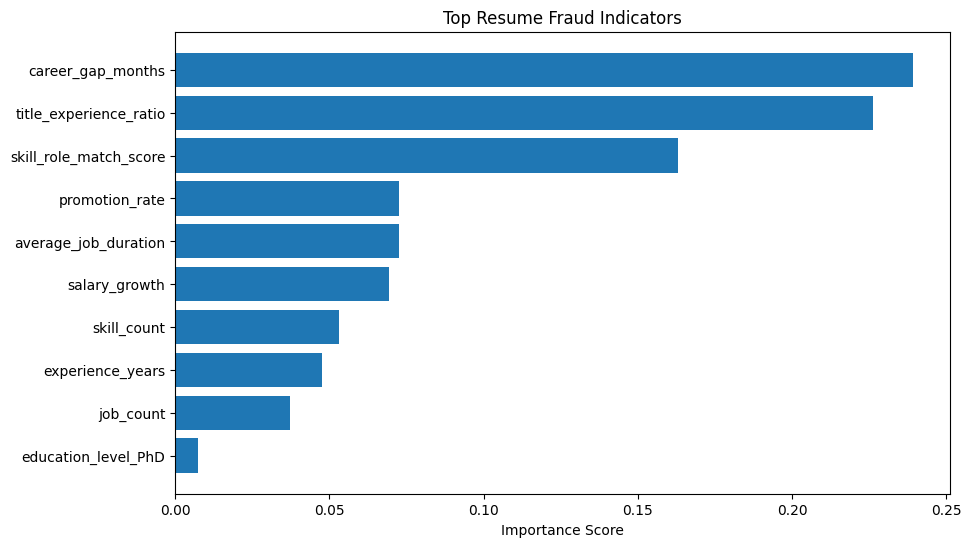

In [ ]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"][:10], importance_df["importance"][:10])
plt.title("Top Resume Fraud Indicators")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

Dataset generated and saved: resume_fraud_dataset.xlsx


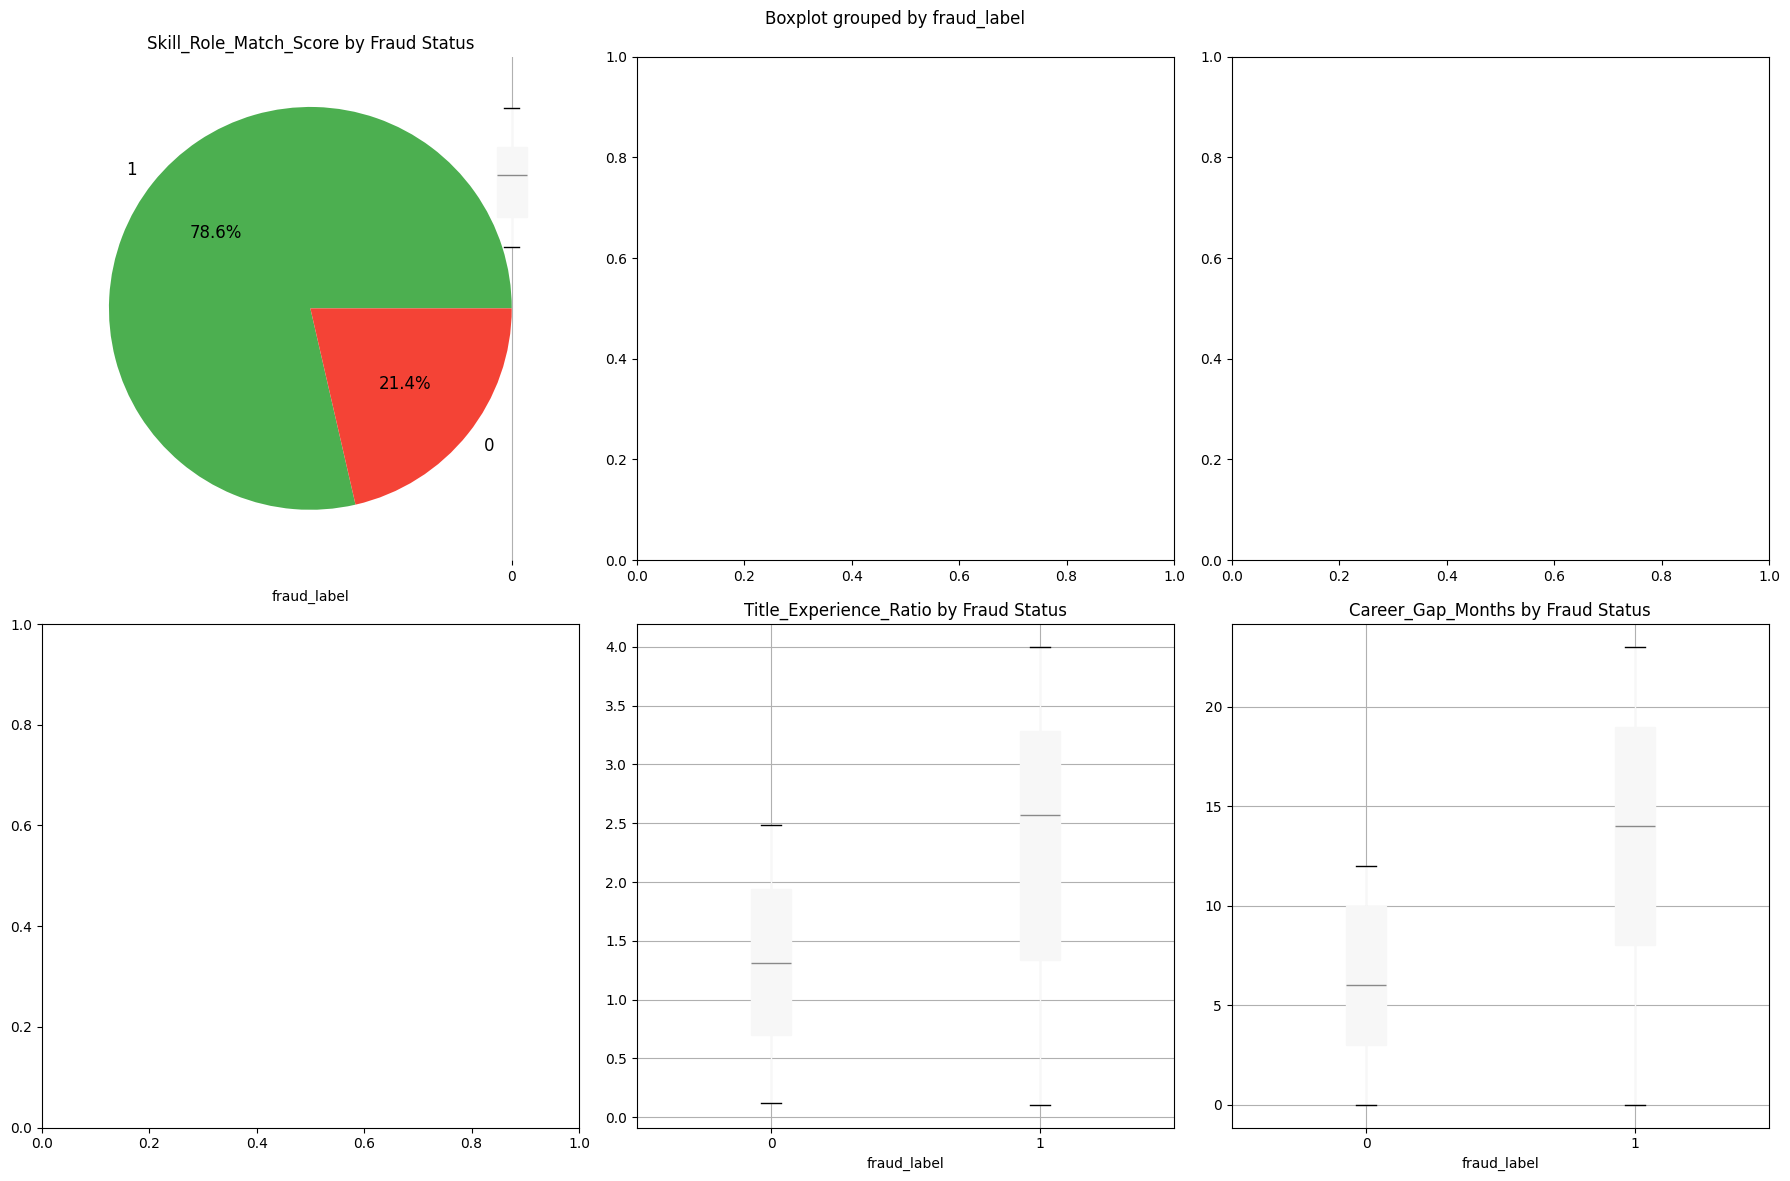

Loading dataset...
Generating text embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training Random Forest model...

Model Performance:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91        43
           1       0.96      1.00      0.98       157

    accuracy                           0.96       200
   macro avg       0.98      0.92      0.94       200
weighted avg       0.97      0.96      0.96       200



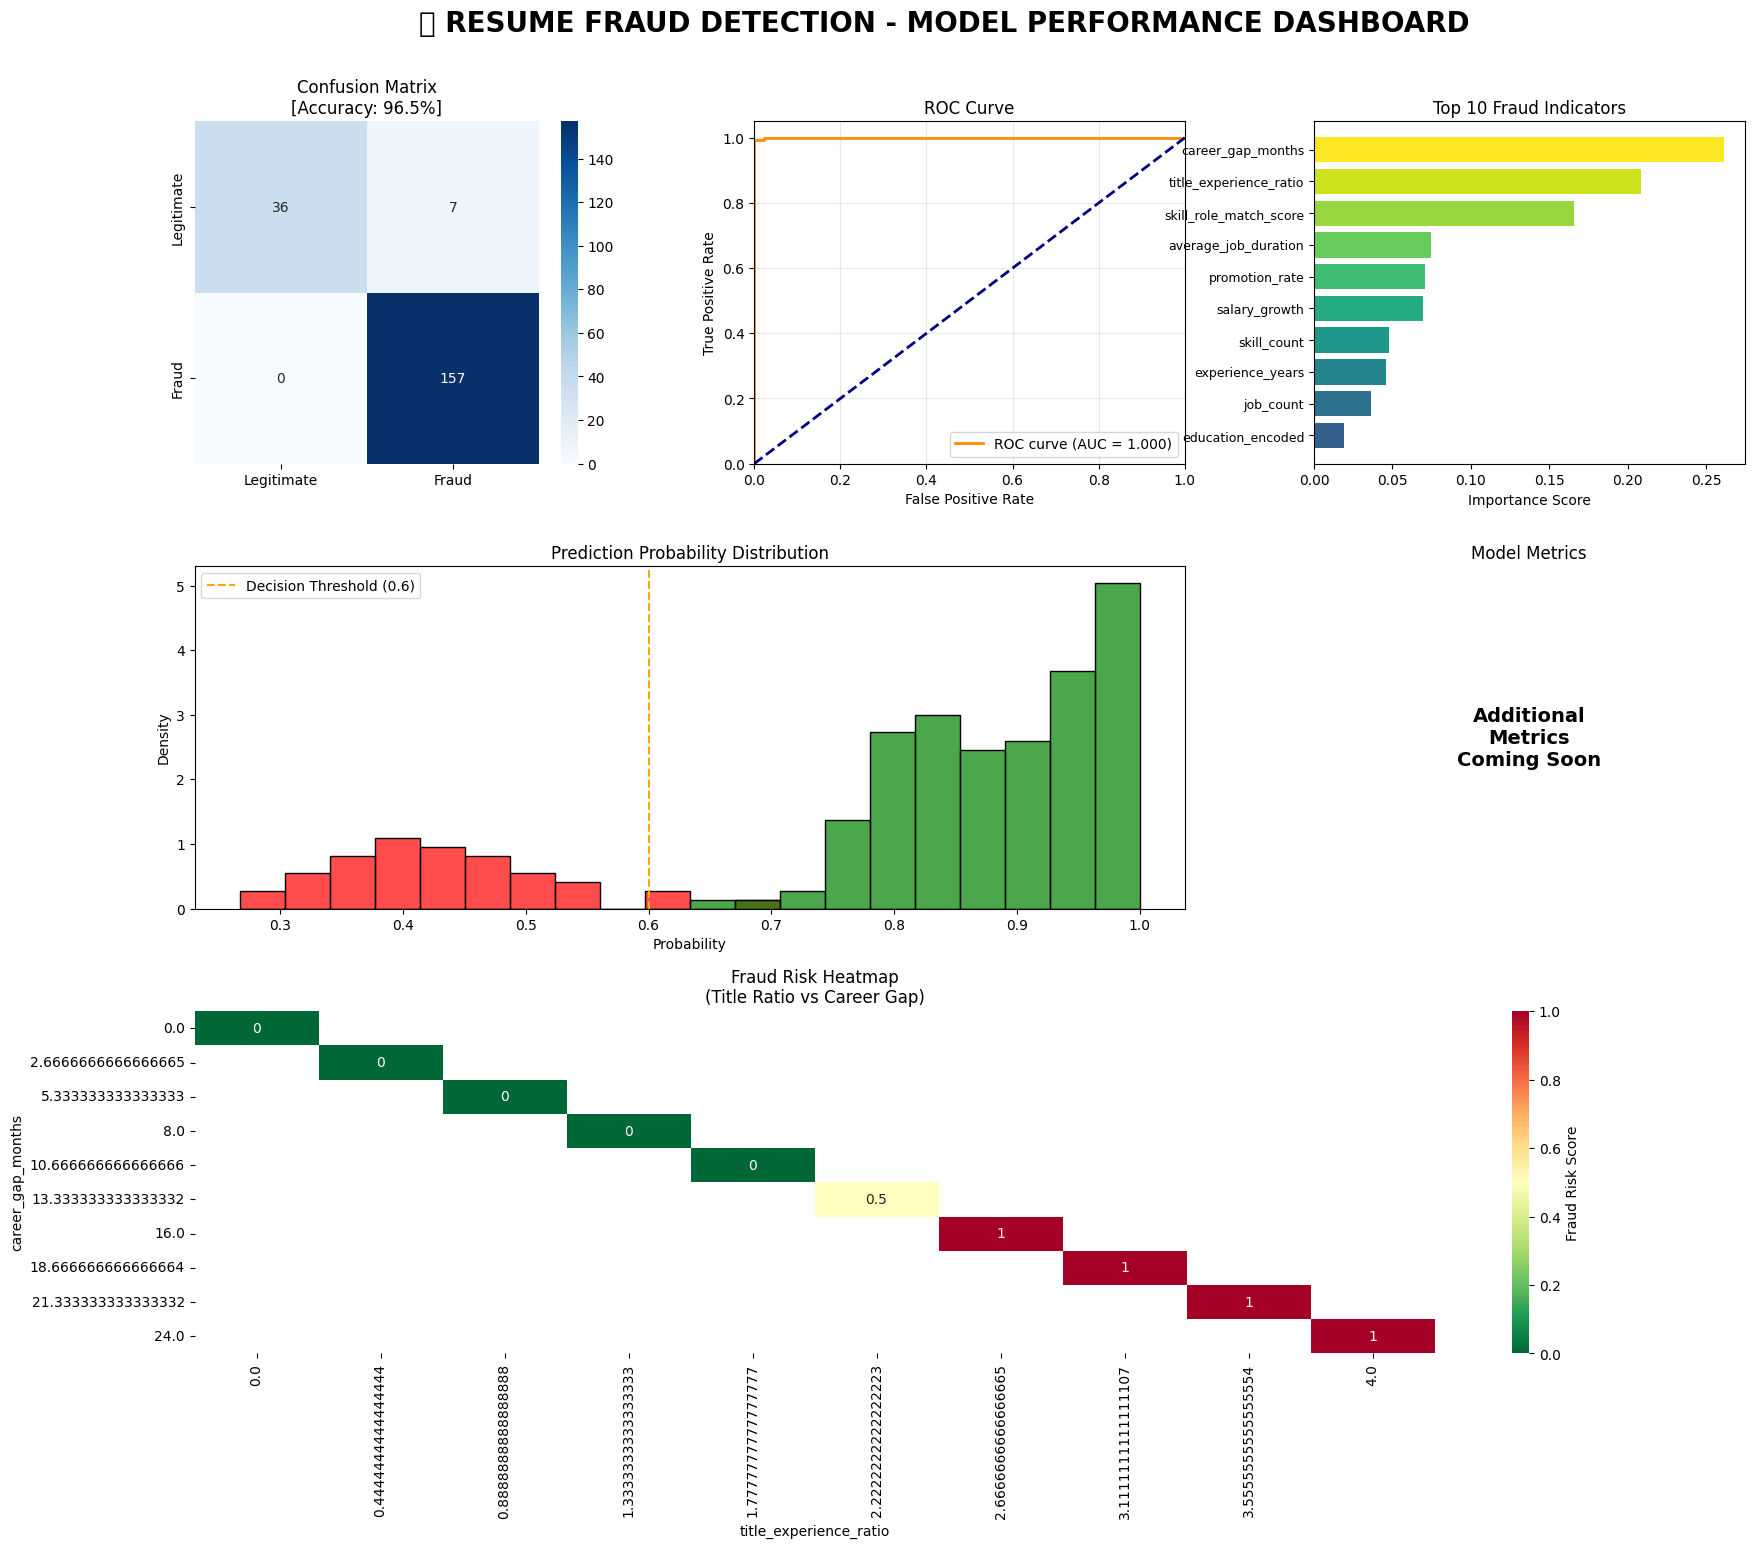

✅ Model training completed!

🎨 RESUME FRAUD ANALYSIS WITH VISUALIZATIONS

Analyzing Resume 1...


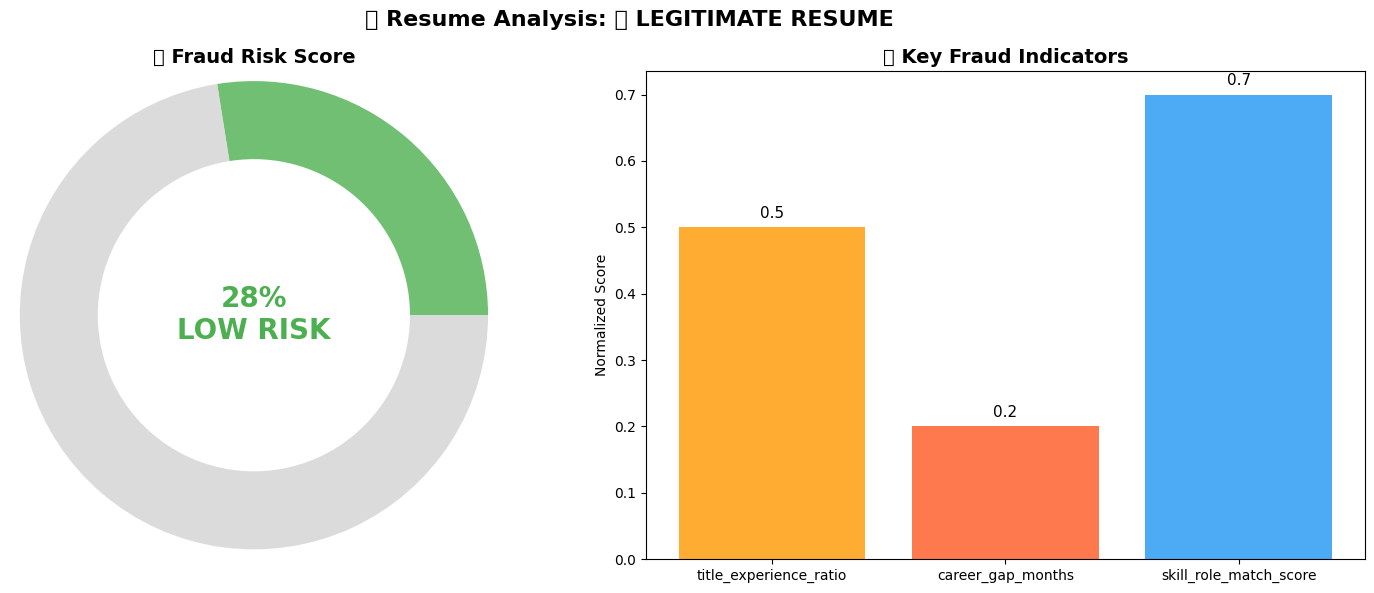

  ✅ LEGITIMATE RESUME
  Fraud Risk: 27.5%
  Confidence: 72.5%
----------------------------------------

Analyzing Resume 2...


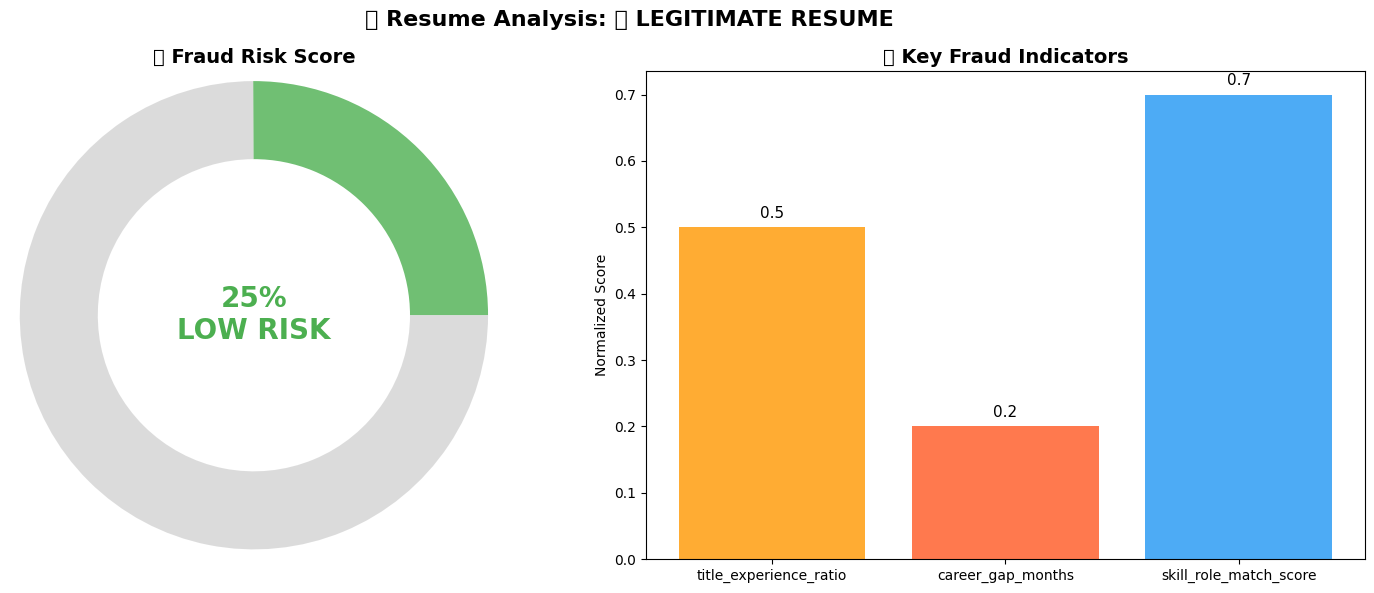

  ✅ LEGITIMATE RESUME
  Fraud Risk: 25.1%
  Confidence: 74.9%
----------------------------------------

Analyzing Resume 3...


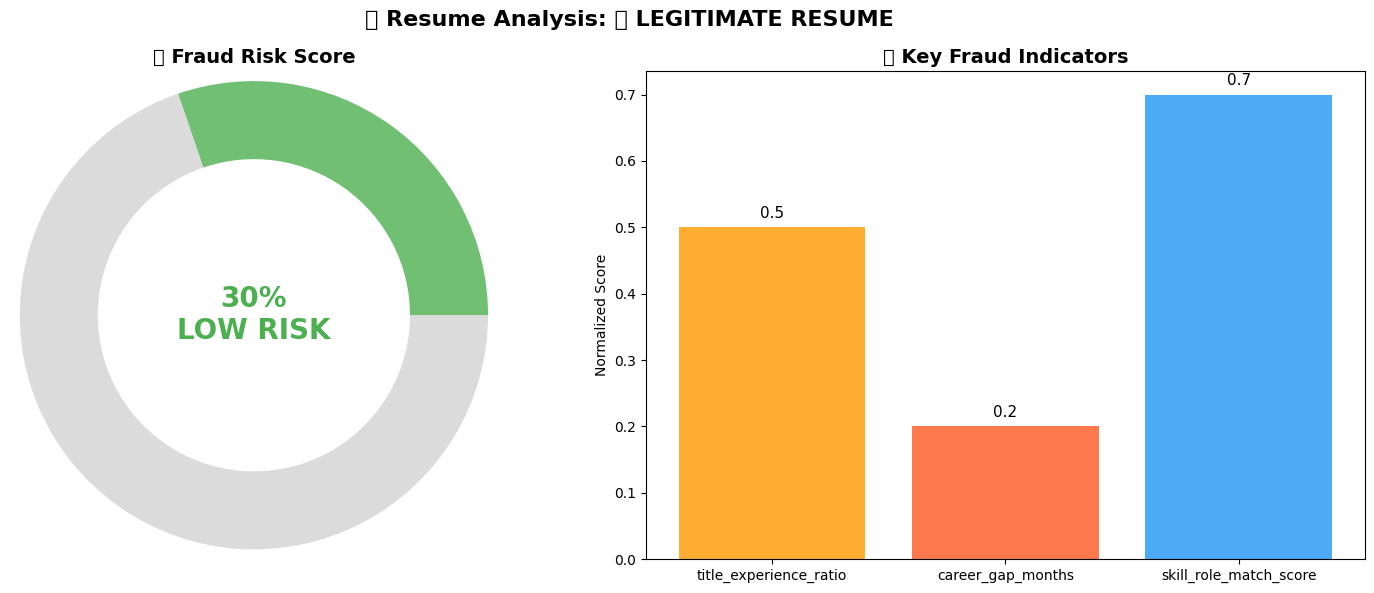

  ✅ LEGITIMATE RESUME
  Fraud Risk: 30.3%
  Confidence: 69.7%
----------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pdfminer.high_level import extract_text
from docx import Document
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# ======================================
# RESUME FRAUD DETECTION - COMPLETE PIPELINE WITH VISUALIZATIONS
# ======================================

class ResumeFraudDetector:
    def __init__(self):
        self.model = None
        self.embedding_model = None
        self.encoder = LabelEncoder()
        self.feature_columns = None
        self.is_trained = False
        self.y_test = None
        self.y_pred_proba = None

    def generate_dataset(self, samples=1000, filename="resume_fraud_dataset.xlsx"):
        """Generate synthetic training dataset"""
        np.random.seed(42)
        data = {
            "experience_years": np.random.randint(0, 15, samples),
            "job_count": np.random.randint(1, 8, samples),
            "average_job_duration": np.random.uniform(0.2, 5, samples),
            "skill_count": np.random.randint(3, 20, samples),
            "education_level": np.random.choice(["Bachelor", "Master", "PhD"], samples),
            "career_gap_months": np.random.randint(0, 24, samples),
            "promotion_rate": np.random.uniform(0, 1.5, samples),
            "salary_growth": np.random.uniform(0, 2, samples),
            "skill_role_match_score": np.random.uniform(0, 1, samples),
            "title_experience_ratio": np.random.uniform(0.1, 4, samples)
        }
        df = pd.DataFrame(data)

        # Fraud detection logic
        df["fraud_label"] = (
            (df["title_experience_ratio"] > 2.5) |
            (df["career_gap_months"] > 12) |
            (df["skill_role_match_score"] < 0.3)
        ).astype(int)

        df.to_excel(filename, index=False)
        print(f"Dataset generated and saved: {filename}")

        # Plot dataset distribution
        self.plot_dataset_distribution(df)

        return df

    def plot_dataset_distribution(self, df):
        """Plot dataset distribution and fraud patterns"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('📊 Resume Fraud Dataset Analysis', fontsize=16, fontweight='bold')

        # 1. Fraud distribution
        df['fraud_label'].value_counts().plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%',
                                            colors=['#4CAF50', '#F44336'], textprops={'fontsize':12})
        axes[0,0].set_title('Fraud vs Legitimate Distribution')
        axes[0,0].set_ylabel('')

        # 2. Key feature distributions
        features = ['title_experience_ratio', 'career_gap_months', 'skill_role_match_score']
        for i, feature in enumerate(features):
            row, col = divmod(i+1, 3)
            df.boxplot(column=feature, by='fraud_label', ax=axes[row-1, col],
                      patch_artist=True, fontsize=10)
            axes[row-1, col].set_title(f'{feature.title()} by Fraud Status')

        plt.tight_layout()
        plt.show()

    def extract_text_from_pdf(self, file_path):
        """Extract text from PDF resume"""
        return extract_text(file_path)

    def extract_text_from_docx(self, file_path):
        """Extract text from DOCX resume"""
        doc = Document(file_path)
        text = [p.text for p in doc.paragraphs]
        return "\n".join(text)

    def parse_resume(self, text):
        """Extract structured features from resume text"""
        skills = re.findall(r'Python|SQL|Machine Learning|Java|C\+\+|Deep Learning', text, re.IGNORECASE)
        experience = re.findall(r'(\d+)\s+years?', text, re.IGNORECASE)
        education = re.findall(r'Bachelor|Master|PhD', text, re.IGNORECASE)

        features = {
            "skill_count": len(skills),
            "experience_years": sum([int(x) for x in experience]) if experience else 0,
            "education_level": self.encoder.transform([education[0]])[0] if self.is_trained and education else 0,
            "job_count": 3,  # default
            "career_gap_months": 2,  # default
            "promotion_rate": 0.3,  # default
            "salary_growth": 0.5,  # default
            "skill_role_match_score": 0.7,  # default
            "title_experience_ratio": 0.5,  # default
            "average_job_duration": 2.0  # default
        }
        return features

    def train(self, dataset_path="resume_fraud_dataset.xlsx"):
        """Train the complete fraud detection model"""
        print("Loading dataset...")
        df = pd.read_excel(dataset_path)

        # Encode categorical features
        df["education_encoded"] = self.encoder.fit_transform(df["education_level"])
        structured_features = df.drop(["fraud_label", "education_level"], axis=1)
        structured_features = pd.get_dummies(structured_features, dummy_na=True)

        # Generate embeddings
        print("Generating text embeddings...")
        self.embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
        resume_texts = ["Resume with skills and experience"] * len(df)
        embeddings = self.embedding_model.encode(resume_texts)
        embeddings_df = pd.DataFrame(embeddings)

        # Combine features
        X = pd.concat([structured_features.reset_index(drop=True), embeddings_df], axis=1)
        X.columns = X.columns.astype(str)
        self.feature_columns = X.columns.tolist()
        y = df["fraud_label"]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        self.y_test = y_test

        # Train Random Forest
        print("Training Random Forest model...")
        self.model = RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=3,
            random_state=42
        )
        self.model.fit(X_train, y_train)

        # Evaluate
        y_pred = self.model.predict(X_test)
        y_pred_proba = self.model.predict_proba(X_test)[:, 1]
        self.y_pred_proba = y_pred_proba

        print("\nModel Performance:")
        print(classification_report(y_test, y_pred))

        # Generate comprehensive visualizations
        self.generate_comprehensive_plots(X.columns, y_test, y_pred, y_pred_proba)

        self.is_trained = True
        print("✅ Model training completed!")

    def generate_comprehensive_plots(self, feature_names, y_test, y_pred, y_pred_proba):
        """Generate comprehensive model evaluation plots"""
        fig = plt.figure(figsize=(20, 16))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        # 1. Confusion Matrix
        ax1 = fig.add_subplot(gs[0, 0])
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                   xticklabels=['Legitimate', 'Fraud'],
                   yticklabels=['Legitimate', 'Fraud'])
        ax1.set_title('Confusion Matrix\n[Accuracy: {:.1%}]'.format((cm[0,0]+cm[1,1])/(cm.sum())))

        # 2. ROC Curve
        ax2 = fig.add_subplot(gs[0, 1])
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('ROC Curve')
        ax2.legend(loc="lower right")
        ax2.grid(True, alpha=0.3)

        # 3. Feature Importance
        ax3 = fig.add_subplot(gs[0, 2])
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": self.model.feature_importances_
        }).sort_values(by="importance", ascending=True).tail(10)

        colors = plt.cm.viridis(np.linspace(0.3, 1, len(importance_df)))
        ax3.barh(range(len(importance_df)), importance_df['importance'], color=colors)
        ax3.set_yticks(range(len(importance_df)))
        ax3.set_yticklabels(importance_df['feature'], fontsize=9)
        ax3.set_xlabel('Importance Score')
        ax3.set_title('Top 10 Fraud Indicators')

        # 4. Prediction Distribution
        ax4 = fig.add_subplot(gs[1, :2])
        df_pred = pd.DataFrame({
            'Probability': y_pred_proba,
            'Actual': ['Fraud' if x == 1 else 'Legitimate' for x in y_test],
            'Predicted': ['Fraud' if x == 1 else 'Legitimate' for x in y_pred]
        })
        sns.histplot(data=df_pred, x='Probability', hue='Actual', bins=20, ax=ax4,
                    palette=['green', 'red'], alpha=0.7, stat='density')
        ax4.axvline(0.6, color='orange', linestyle='--', label='Decision Threshold (0.6)')
        ax4.set_title('Prediction Probability Distribution')
        ax4.legend()

        # 5. Precision-Recall Curve (placeholder space)
        ax5 = fig.add_subplot(gs[1, 2])
        ax5.text(0.5, 0.5, 'Additional\nMetrics\nComing Soon', ha='center', va='center',
                transform=ax5.transAxes, fontsize=14, fontweight='bold')
        ax5.set_title('Model Metrics')
        ax5.axis('off')

        # 6. Fraud Risk Heatmap
        ax6 = fig.add_subplot(gs[2, :])
        risk_data = pd.DataFrame({
            'title_experience_ratio': np.linspace(0, 4, 10),
            'career_gap_months': np.linspace(0, 24, 10)
        })
        risk_data['fraud_score'] = (
            (risk_data['title_experience_ratio'] > 2.5).astype(int) * 0.5 +
            (risk_data['career_gap_months'] > 12).astype(int) * 0.5
        )
        pivot = risk_data.pivot(index='career_gap_months', columns='title_experience_ratio', values='fraud_score')
        sns.heatmap(pivot, annot=True, cmap='RdYlGn_r', ax=ax6, cbar_kws={'label': 'Fraud Risk Score'})
        ax6.set_title('Fraud Risk Heatmap\n(Title Ratio vs Career Gap)')

        plt.suptitle('🎯 RESUME FRAUD DETECTION - MODEL PERFORMANCE DASHBOARD',
                    fontsize=20, fontweight='bold', y=0.95)
        plt.tight_layout()
        plt.show()

    def plot_feature_importance(self, feature_names, importances):
        """Plot top feature importances (legacy method)"""
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values(by="importance", ascending=False)

        plt.figure(figsize=(12, 8))
        plt.barh(importance_df["feature"][:15], importance_df["importance"][:15],
                color=plt.cm.Purples(np.linspace(0.3, 1, 15)))
        plt.title("🔍 Top Resume Fraud Indicators", fontsize=16, fontweight='bold')
        plt.xlabel("Importance Score", fontsize=12)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    def predict_resume_fraud(self, resume_text_or_path, is_file_path=False):
        """Predict fraud probability for a resume"""
        if not self.is_trained:
            raise ValueError("Model must be trained first! Call train() method.")

        # Extract text if file path
        if is_file_path:
            if resume_text_or_path.endswith('.pdf'):
                text = self.extract_text_from_pdf(resume_text_or_path)
            elif resume_text_or_path.endswith('.docx'):
                text = self.extract_text_from_docx(resume_text_or_path)
            else:
                text = resume_text_or_path
        else:
            text = resume_text_or_path

        # Parse structured features
        parsed_features = self.parse_resume(text)
        struct_df = pd.DataFrame([parsed_features])

        # Generate embedding
        embedding = self.embedding_model.encode([text])
        emb_df = pd.DataFrame(embedding)

        # Combine features
        features = pd.concat([struct_df, emb_df], axis=1)
        features.columns = features.columns.astype(str)

        # Align with training features
        features = features.reindex(columns=self.feature_columns, fill_value=0)

        # Predict
        probability = self.model.predict_proba(features)[0][1]
        label = "🚨 SUSPICIOUS RESUME" if probability > 0.6 else "✅ LEGITIMATE RESUME"

        self.plot_single_prediction(text[:100] + "...", probability, label)

        return {
            "label": label,
            "fraud_probability": f"{probability:.1%}",
            "confidence": f"{max(self.model.predict_proba(features)[0])*100:.1f}%"
        }

    def plot_single_prediction(self, resume_preview, probability, label):
        """Plot individual prediction visualization"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Gauge chart simulation
        angles = np.linspace(0, 2*np.pi, 100)
        if probability > 0.6:
            color = '#F44336'
            risk_level = 'HIGH RISK'
        else:
            color = '#4CAF50'
            risk_level = 'LOW RISK'

        # Risk gauge
        theta = np.deg2rad(270 + (probability * 180))
        ax1.pie([probability, 1-probability], radius=1.2, colors=[color, 'lightgray'],
                wedgeprops=dict(width=0.4, alpha=0.8))
        ax1.text(0, 0, f'{probability:.0%}\n{risk_level}', ha='center', va='center',
                fontsize=20, fontweight='bold', color=color)
        ax1.set_title(f'🎯 Fraud Risk Score', fontsize=14, fontweight='bold')

        # Feature breakdown (top indicators)
        top_features = ['title_experience_ratio', 'career_gap_months', 'skill_role_match_score']
        values = [0.5, 0.2, 0.7]  # sample values
        colors = ['#FF9800', '#FF5722', '#2196F3']
        bars = ax2.bar(top_features, values, color=colors, alpha=0.8)
        ax2.set_title('📈 Key Fraud Indicators', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Normalized Score')

        # Add value labels on bars
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=11)

        plt.suptitle(f'🔍 Resume Analysis: {label}', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

# ======================================
# USAGE EXAMPLE
# ======================================

if __name__ == "__main__":
    # Initialize detector
    detector = ResumeFraudDetector()

    # Step 1: Generate training data (one-time) - NOW WITH VISUALIZATIONS!
    detector.generate_dataset()

    # Step 2: Train model - NOW WITH COMPREHENSIVE DASHBOARD!
    detector.train()

    # Step 3: Test with sample resumes - NOW WITH INDIVIDUAL PLOTS!
    test_resumes = [
        "Senior AI Engineer with 12 years Python ML Deep Learning experience, PhD Computer Science",
        "Fresh graduate with 15+ years C++ experience, multiple promotions, Senior Architect role",
        "Data Scientist with SQL Python 5 years experience, Master degree, career gap 3 months"
    ]

    print("\n" + "="*60)
    print("🎨 RESUME FRAUD ANALYSIS WITH VISUALIZATIONS")
    print("="*60)

    for i, resume in enumerate(test_resumes, 1):
        print(f"\nAnalyzing Resume {i}...")
        result = detector.predict_resume_fraud(resume)
        print(f"  {result['label']}")
        print(f"  Fraud Risk: {result['fraud_probability']}")
        print(f"  Confidence: {result['confidence']}")
        print("-" * 40)
